## Preprocessing Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Reading the dataset

In [2]:
import sys
sys.path.append('..')

from src.data import load_data
df = load_data('../data/Wholesale_Customers_Data.csv')
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


### Outlier detection

#### Ploting box plot to outlier analysis (without Log Transformation)

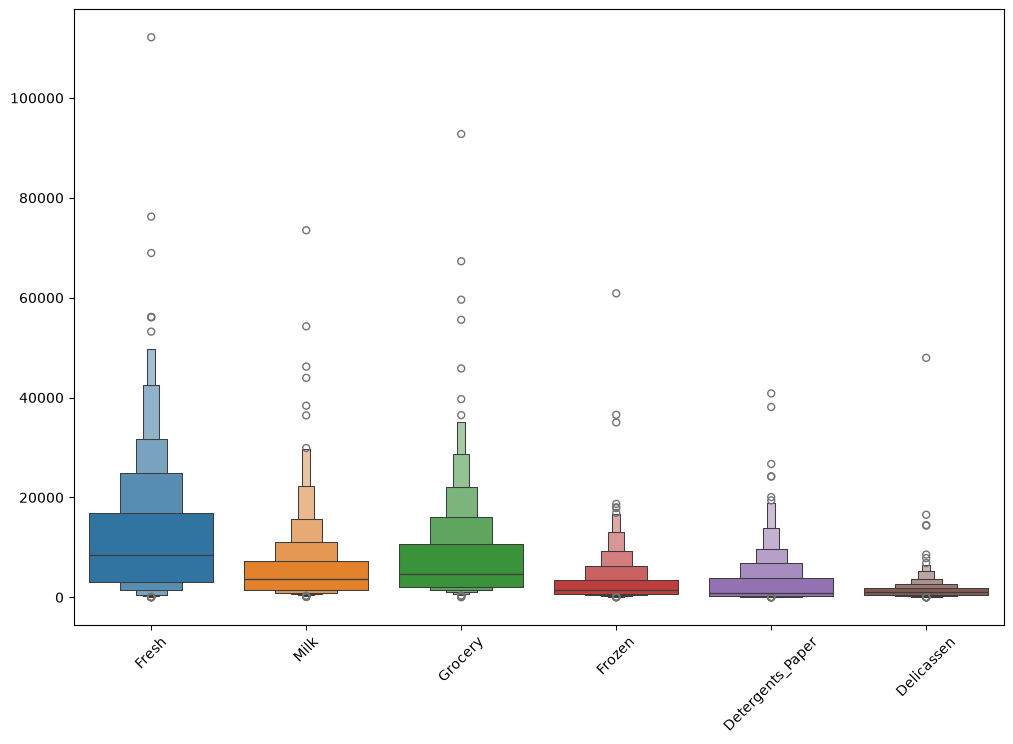

In [3]:
# feature Selection
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

plt.figure(figsize= (12 , 8))
sns.boxenplot(data= df[features])
plt.xticks(rotation= 45)
plt.show()

#### The box plot reveals numerous outliers. This may be due to significant skewness in the data distribution.Therefore, we will use a log transformation to improve the data distribution.

In [4]:
from src.preprocessing import Log_Transform, remove_outliers_IQR, show_outliers_count_IQR

df_log = Log_Transform(df , features)
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


<Figure size 1200x800 with 0 Axes>

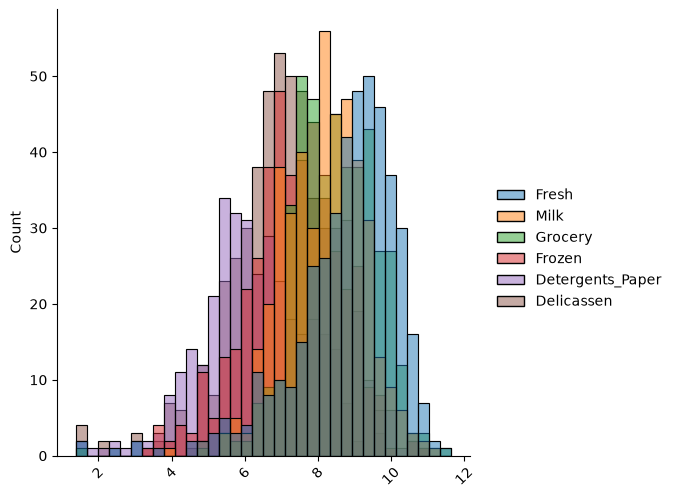

In [5]:
plt.figure(figsize= (12 , 8))

sns.displot(data= df_log[features])
plt.xticks(rotation= 45)
plt.show()

#### Now the skewness is lower than original data and data distribution improved.

#### Ploting box plot to outlier analysis (with Log Transformation)

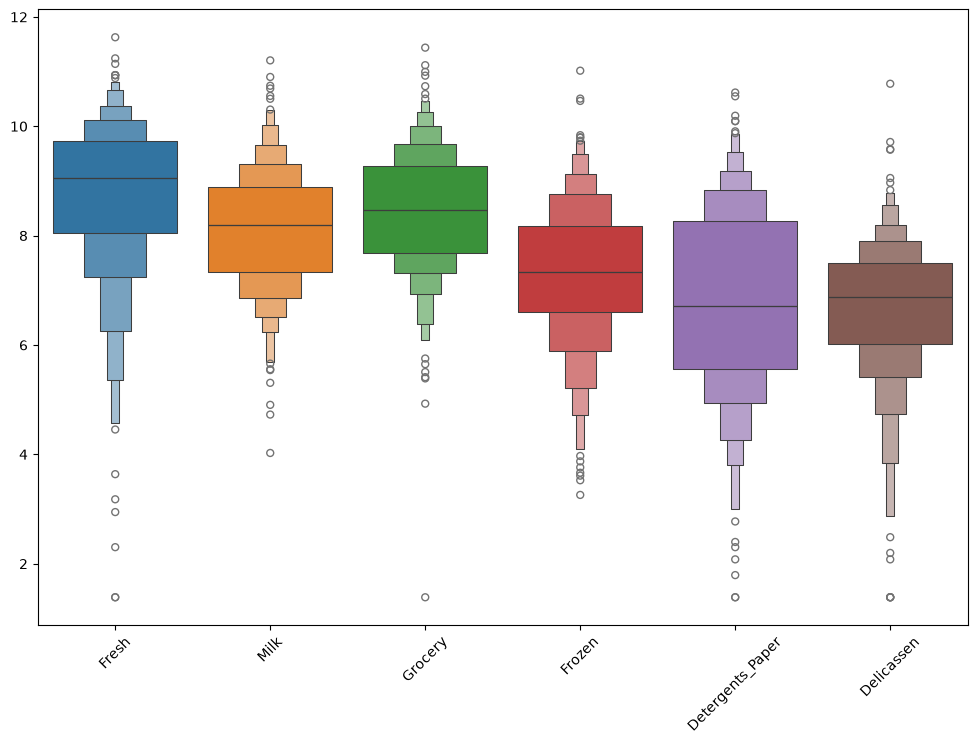

In [6]:
plt.figure(figsize= (12 , 8))

sns.boxenplot(data= df_log[features])
plt.xticks(rotation= 45)
plt.show()

In [7]:
show_outliers_count_IQR(df_log, features)

Fresh  : 16
Milk  : 4
Grocery  : 2
Frozen  : 10
Detergents_Paper  : 2
Delicassen  : 14


#### Outliers were identified using the IQR method after log transformation and were evaluated before removal.

In [8]:
df_clean = remove_outliers_IQR(df_log, features)

#### Box Plot analysis after removing outliers

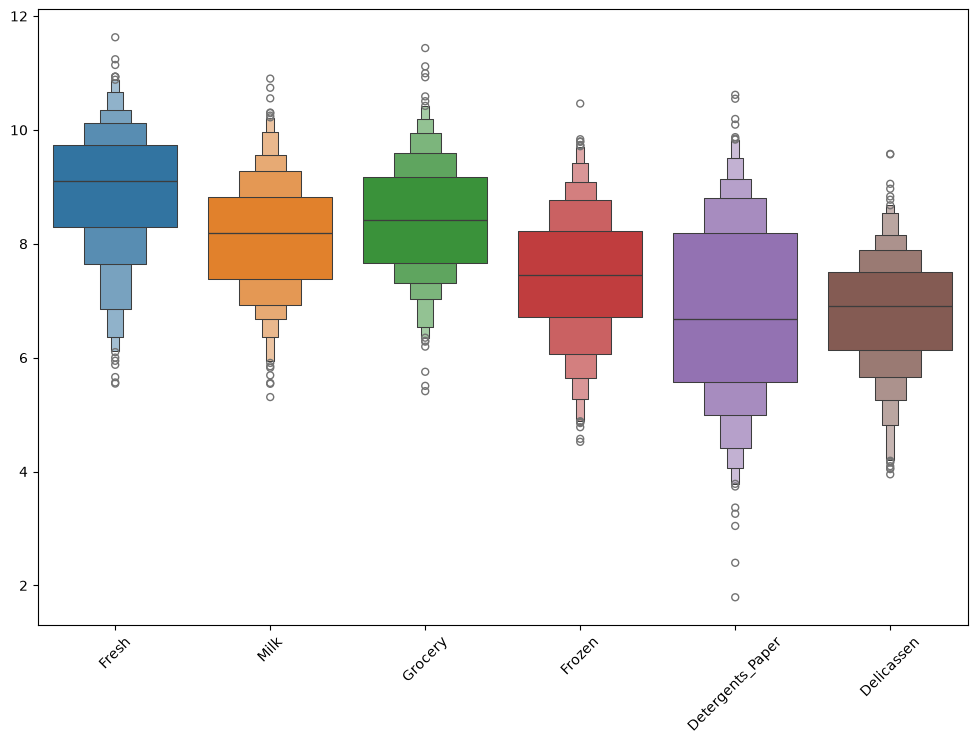

In [9]:
plt.figure(figsize= (12 , 8))

sns.boxenplot(data= df_clean[features])
plt.xticks(rotation= 45)
plt.show()

#### Now the dataset is clean. 
#### Saving cealed dataset CSV file

In [11]:
from src.data import save_data
save_data(df_clean, 'cleaned_log_data')